# 02 — Time-Domain QC: Deformation & Strain in High Resolution

The η *summaries* now live in the frequency domain (notebook 03). This
notebook keeps the **time-domain window pipeline** for what it is best at:
looking at the cable deformation, per-segment strain and elongation signals in
high temporal resolution — QC, method comparison (three strain estimators) and
**example figures for the thesis** that show how the efficiencies are built
from the raw small-scale displacements.

Pipeline per (dataset, target frequency) — `analysis.per_frequency_qc`:
1. Window ±N cycles around the log-sweep arrival time of f_target.
2. Zero-phase Butterworth bandpass (± `BANDWIDTH_ABS_HZ` Hz) of cable + shaker
   velocities.
3. FFT integration → displacement (divide by iω).
4. Strain by three methods: M1 spatial gradient ∂(u·ê)/∂s, M2 per-segment 3-D
   arc-length, M3 Fourier-domain gradient.
5. Cable elongation δxₗ vs reference elongation → η(t), median.

| § | Content |
|---|---|
| 1 | Dataset selection & loading |
| 2 | Per-frequency QC run + static figure |
| 3 | Interactive QC dashboard |
| 4 | Strain-method comparison dashboard |
| 5 | Thesis example: small-scale displacement/strain window → export |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Editable reload while iterating on the package
%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, export

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.titlesize": 11, "axes.labelsize": 10, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2,
})
print(f"{len(la.ALL_DATASETS)} datasets in catalogue.")

46 datasets in catalogue.


---
## § 1  Dataset selection & loading

In [3]:
# QC is per-dataset — keep the selection small.
ACTIVE_LABELS = ["Cable7_15cm"]
# ACTIVE_LABELS = [f"Cable{i}_10cm" for i in range(1, 8)]

DATASETS = config.select_datasets(ACTIVE_LABELS)
for cfg in DATASETS:
    io.load_cable_dataset(cfg)
    analysis.prepare_geometry(cfg, sag_use_3d=True, sag_use_parabola=True)
    print(f"  {cfg['label']:18s}  L={cfg['chord_len']*1e3:.1f} mm  "
          f"sag={cfg['static_sag']*1e3:.3f} mm  eta_pred={cfg['eta_pred']:.3f}")

  [Cable7_15cm] shaker active channel: idx=17 (of 18 channels; 1 non-zero)
  Cable7_15cm         L=141.9 mm  sag=0.327 mm  eta_pred=0.791


---
## § 2  Per-frequency QC

Run the window pipeline for a handful of frequencies and show the full QC
figure for one of them (space-time fields, strain comparison, η(t)).

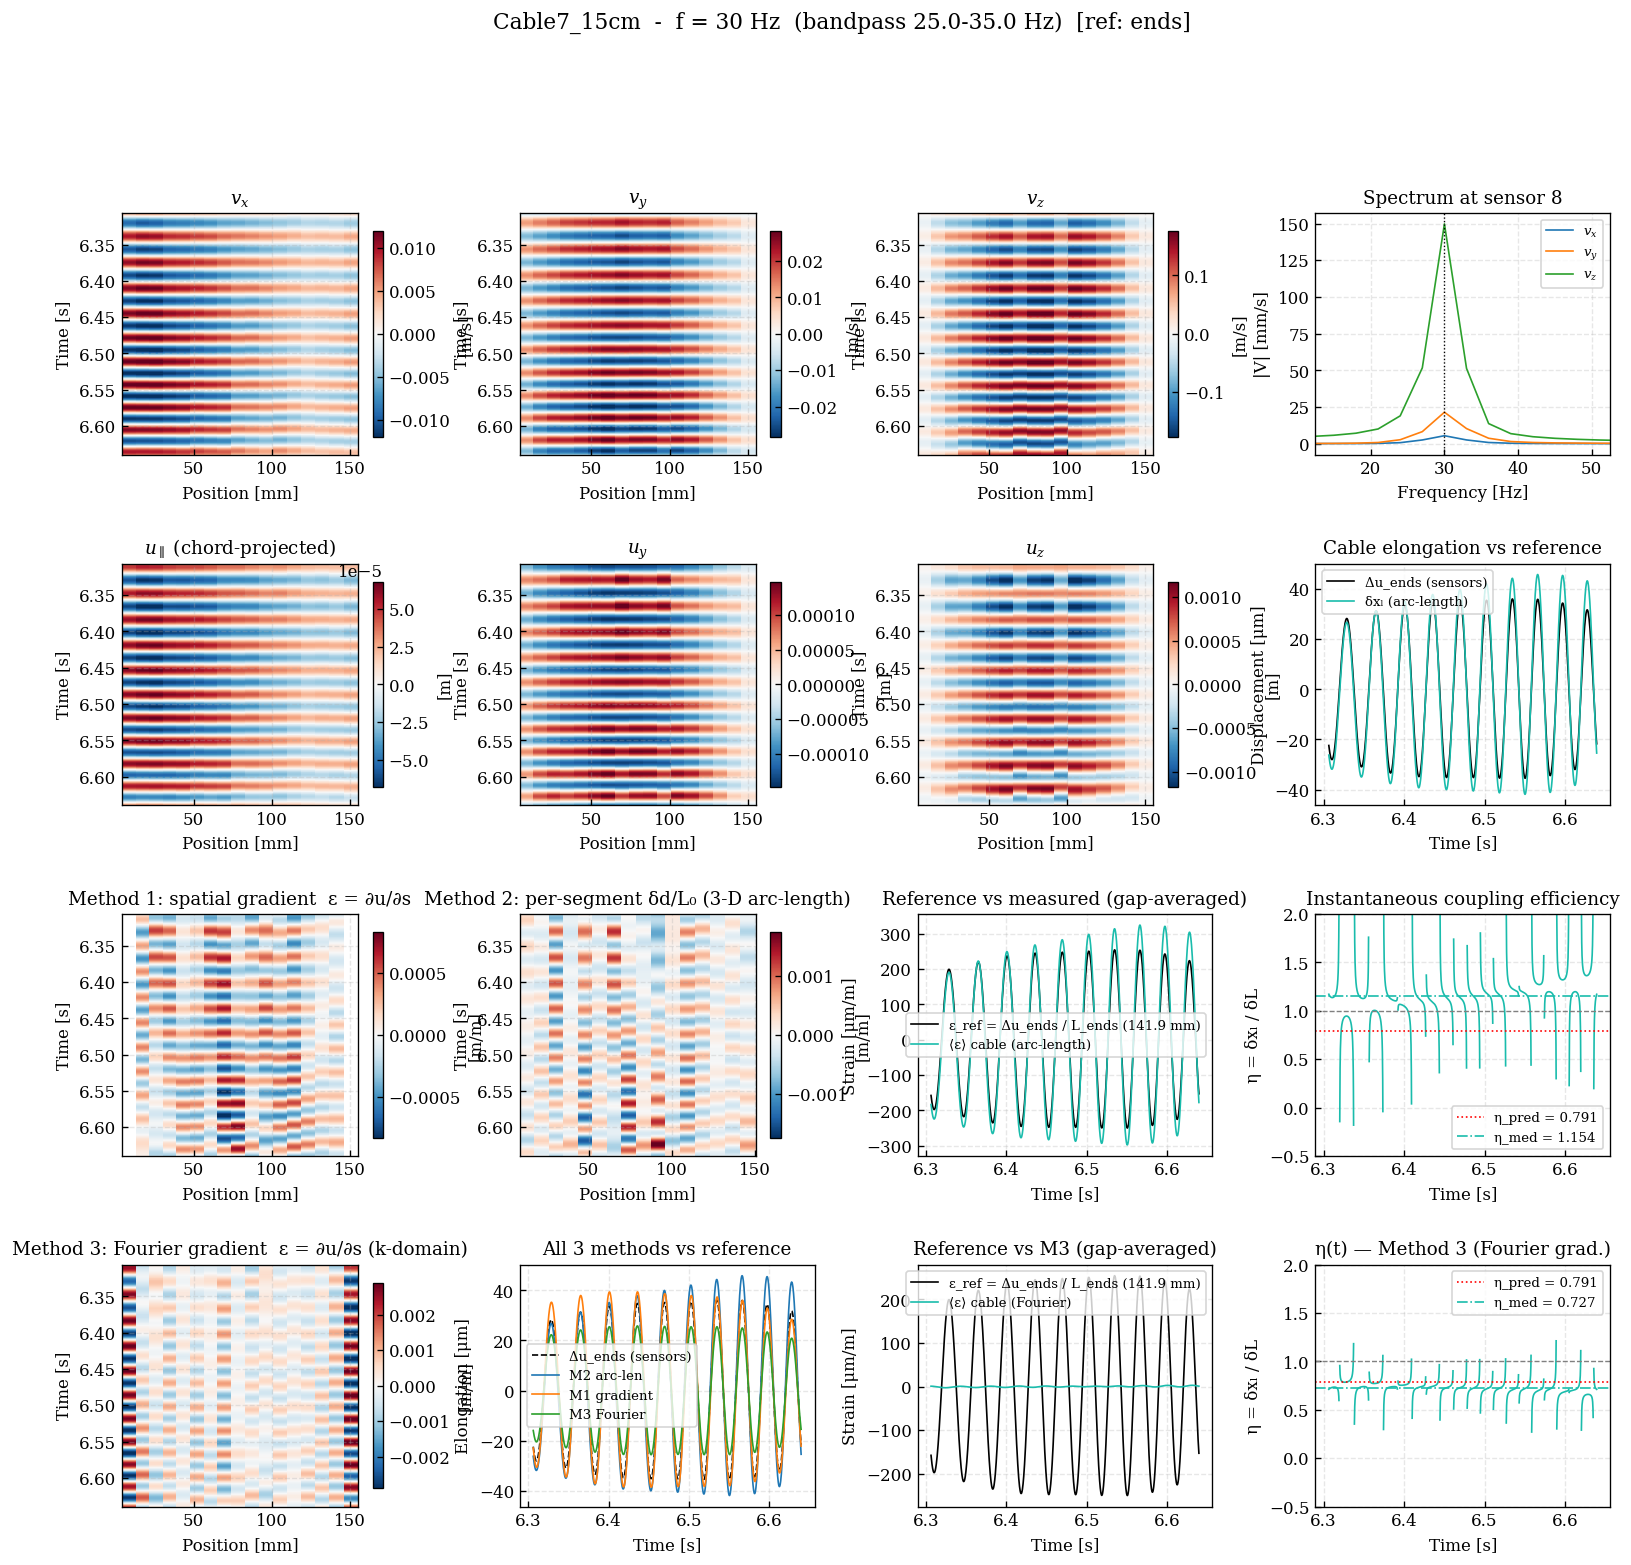

In [4]:
QC_FREQS = [10, 30, 100, 300]     # Hz — edit freely

for cfg in DATASETS:
    cfg.setdefault('per_freq', {})
    for f in QC_FREQS:
        res = analysis.per_frequency_qc(cfg, f)
        if res is not None:
            cfg['per_freq'][f] = res

cfg0 = DATASETS[0]
plotting.plot_per_frequency_qc(cfg0, cfg0['per_freq'][QC_FREQS[1]], ref='ends')

---
## § 3  Interactive QC dashboard

Pick cable / frequency / bandwidth / window and re-run the analysis on
demand.

In [ ]:
from ldv_analysis import widgets
widgets.qc_dashboard(DATASETS)

---
## § 4  Strain-method comparison dashboard (M1 / M2 / M3)

In [ ]:
widgets.strain_comparison_dashboard(DATASETS)

---
## § 5  Thesis example window → export

Exports one windowed example (default 30 Hz) with everything needed to draw
"how η is measured" figures in the paper-figure notebook: the reference
elongation δL(t), endpoint elongation Δu_ends(t), the cable elongation δxₗ(t)
from all three strain methods, and the per-segment strain field.

In [7]:
F_EXAMPLE = 30                     # Hz
cfg0 = DATASETS[0]
res = cfg0['per_freq'].get(F_EXAMPLE) or analysis.per_frequency_qc(cfg0, F_EXAMPLE)

s_coords = np.array([np.dot(cfg0['XYZ'][i] - cfg0['XYZ'][0], cfg0['chord_unit'])
                     for i in range(len(cfg0['XYZ']))])

export.export_results(
    'timedomain_example',
    meta=dict(label=cfg0['label'], f_target=F_EXAMPLE,
              f_lo=res['f_lo'], f_hi=res['f_hi'],
              eta_med_ends=res['eta_med_ends'],
              eta_pred=cfg0['eta_pred']),
    t=res['t_win'],
    delta_L=res['delta_L_win'],            # chord-projected shaker elongation
    delta_ends=res['delta_ends'],          # endpoint-pair elongation
    delta_xl_m1=res['delta_xl_m1'],        # integrated gradient strain (M1)
    delta_xl_m2=res['delta_xl'],           # arc-length elongation (M2)
    delta_xl_m3=res['delta_xl_m3'],        # Fourier-gradient elongation (M3)
    seg_strain=res['seg_strain'],          # (N_t, N_seg) per-segment strain
    L0_seg=res['L0_seg'],
    strain_grad=np.nan_to_num(res['strain_grad']),
    s_sensors=s_coords,
    eta_t_ends=res['eta_t_ends'],
)

exported timedomain_example.npz: t(1666,), delta_L(1666,), delta_ends(1666,), delta_xl_m1(1666,), delta_xl_m2(1666,), delta_xl_m3(1666,), seg_strain(1666, 16), L0_seg(16,), strain_grad(1666, 17), s_sensors(17,), eta_t_ends(1666,)


WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/timedomain_example.npz')